In [1]:
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_4.npz"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]


# pairwise distances
from scipy.spatial.distance import pdist, squareform
distances = pdist(_embeddings, metric="euclidean")

max_distance = np.max(distances)
min_distance = np.min(distances)
average_distance = np.mean(distances)

diff = max_distance - min_distance
y = diff / min_distance

print(f"Max distance: {max_distance}")
print(f"Min distance: {min_distance}")
print(f"Difference: {diff}")
print(f"Difference / Min distance: {y}")
print(f"Average distance: {average_distance}")

Max distance: 10.754306240374394
Min distance: 0.17495091395903678
Difference: 10.579355326415357
Difference / Min distance: 60.47042045686266
Average distance: 3.498336139176263


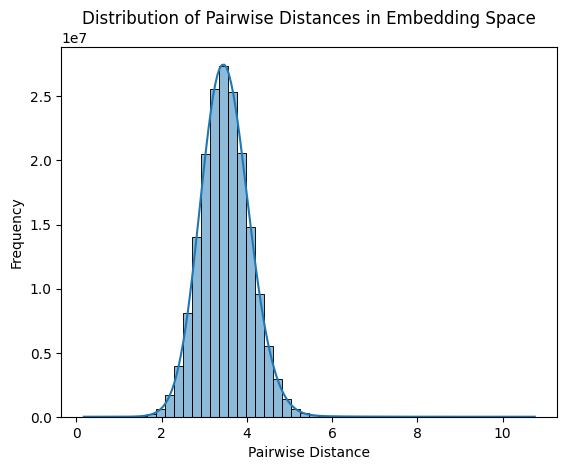

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(distances, bins=50, kde=True)
plt.xlabel("Pairwise Distance")
plt.ylabel("Frequency") 
plt.title("Distribution of Pairwise Distances in Embedding Space")
plt.show()

Dimension 0: Mean = 0.3651, Std Dev = 0.4382
Dimension 1: Mean = 0.0934, Std Dev = 0.3804
Dimension 2: Mean = -1.1152, Std Dev = 0.5423
Dimension 3: Mean = 0.3985, Std Dev = 0.3833
Dimension 4: Mean = -0.6146, Std Dev = 0.5031
Dimension 5: Mean = 0.7554, Std Dev = 0.4393
Dimension 6: Mean = 0.0099, Std Dev = 0.0202
Dimension 7: Mean = -0.2966, Std Dev = 0.4759
Dimension 8: Mean = 0.8116, Std Dev = 0.3279
Dimension 9: Mean = -0.2336, Std Dev = 0.4018
Dimension 10: Mean = 0.5799, Std Dev = 0.4342
Dimension 11: Mean = -0.0019, Std Dev = 0.0446
Dimension 12: Mean = 0.0404, Std Dev = 0.4274
Dimension 13: Mean = -0.1155, Std Dev = 0.8236
Dimension 14: Mean = -0.9909, Std Dev = 0.4457
Dimension 15: Mean = 0.4630, Std Dev = 0.3864
Dimension 16: Mean = 0.0985, Std Dev = 0.2795
Dimension 17: Mean = -0.1918, Std Dev = 0.4520
Dimension 18: Mean = 0.3350, Std Dev = 0.5343
Dimension 19: Mean = -0.2501, Std Dev = 0.4566
Dimension 20: Mean = 0.0562, Std Dev = 0.0247
Dimension 21: Mean = 0.1243, Std De

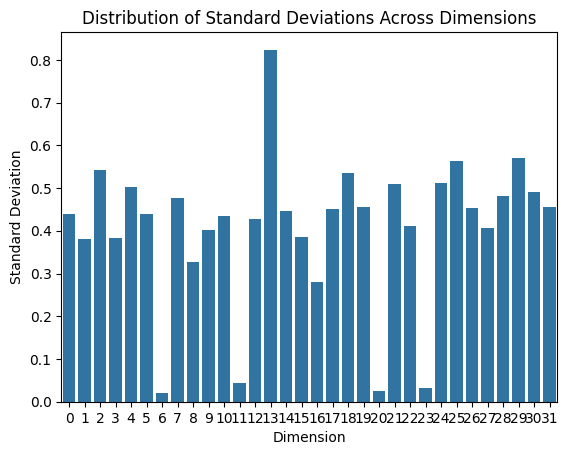

In [3]:
# for each dimention calculate the mean and std_deviation
for i in range(_embeddings.shape[1]):
    dim_values = _embeddings[:, i]
    mean = np.mean(dim_values)
    std_dev = np.std(dim_values)
    print(f"Dimension {i}: Mean = {mean:.4f}, Std Dev = {std_dev:.4f}")
    
# make a barplot of the std_deviation of each dimension
std_devs = [np.std(_embeddings[:, i]) for i in range(_embeddings.shape[1])]
sns.barplot(x=list(range(len(std_devs))), y=std_devs)
plt.xlabel("Dimension")
plt.ylabel("Standard Deviation")
plt.title("Distribution of Standard Deviations Across Dimensions")
plt.show()

Autovalori: [8.39278109e-01 6.54601484e-01 5.11478389e-01 4.76708243e-01
 4.15002542e-01 3.79371584e-01 3.19721026e-01 2.82142368e-01
 2.65878514e-01 2.52217365e-01 2.41850792e-01 2.12611376e-01
 1.94489733e-01 1.76377222e-01 1.64256462e-01 1.32188517e-01
 1.18271762e-01 1.13403865e-01 9.22638997e-02 8.73425364e-02
 7.08950863e-02 6.46480523e-02 5.32014751e-02 4.99746810e-02
 4.33159019e-02 3.50598719e-02 2.56838448e-02 1.25295638e-02
 7.71209561e-04 2.11045895e-04 1.42089086e-04 7.04419707e-05]


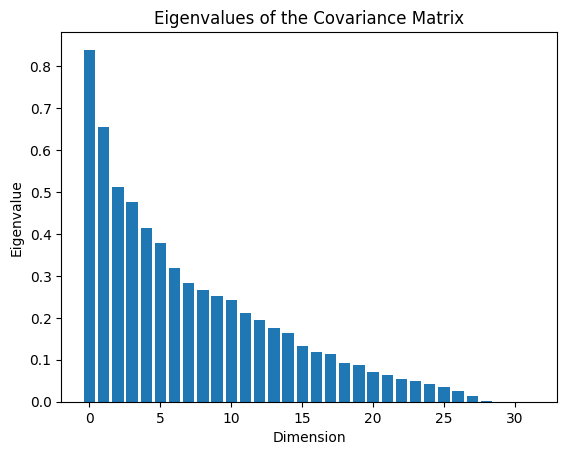

In [4]:
# covariance matrix and eigenvalues
cov_matrix = np.cov(_embeddings, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Autovalori:", eigenvalues)

# bar plot of eigenvalues
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.xlabel("Dimension")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of the Covariance Matrix")
plt.show()